# 자치구별 월간 119 이송 건수 예측
- 목표 : 전월·전년 정보로 이번 달 이송 건수(transport_cnt) 예측
- 방식 : 데이터 2종 × 출처 사용 여부 2가지 = 실험 4개, 실험마다 모델 6종 비교
- 최종 선택 : 24개 조합 중 정확도 최고 조합
- 정확도 : (1 - MAPE) × 100, 실제값 대비 평균 오차 비율을 뺀 값

## 0. 라이브러리 및 기본 설정
- 한글 폰트 설정 : 그래프 한글 깨짐 방지
- 결과 폴더 생성 : 모델·그래프·예측표 저장 위치

In [1]:
import os
import pickle
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             mean_absolute_percentage_error, r2_score)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping

if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumGothic')
plt.rc('axes', unicode_minus=False)

DATA_DIR = 'C:/ai/source/09_Project/ml_data'        # 학습용 csv 폴더
RESULT_DIR = 'C:/ai/source/09_Project/ml_result'    # 결과 저장 폴더
os.makedirs(RESULT_DIR, exist_ok=True)

target = 'transport_cnt'

## 1. 데이터 불러오기
- transport_dataset : 전체 컬럼 (1,566행)
- transport_selected : max_missing=0.5 기준으로 고른 12개 컬럼 (575행)

In [2]:
full = pd.read_csv(f'{DATA_DIR}/transport_dataset.csv', encoding='utf-8-sig')
sel = pd.read_csv(f'{DATA_DIR}/transport_selected.csv', encoding='utf-8-sig')

full['ds'] = pd.to_datetime(full['ds'])
sel['ds'] = pd.to_datetime(sel['ds'])

print(full.shape, sel.shape)
print(full.groupby('출처')['ds'].agg(['min', 'max', 'count']))

(1566, 52) (575, 16)
                      min        max  count
출처                                         
API_2017_2019  2017-01-01 2019-04-01    666
API_2025       2025-01-01 2025-12-01    300
건별집계_2021_2022 2021-01-01 2022-12-01    600


## 2. 출처와 빈 기간 확인
- 빈 기간 : 2019년 5월~2020년 12월, 2023~2024년 자료 없음
- 빈 기간 직후 달 : 전월 값이 없어서 학습에 못 씀
- 출처별 평균 : 집계 기준 차이로 수준이 다를 수 있음

출처
API_2017_2019     1192.0
API_2025           922.0
건별집계_2021_2022    1118.0
Name: transport_cnt, dtype: float64


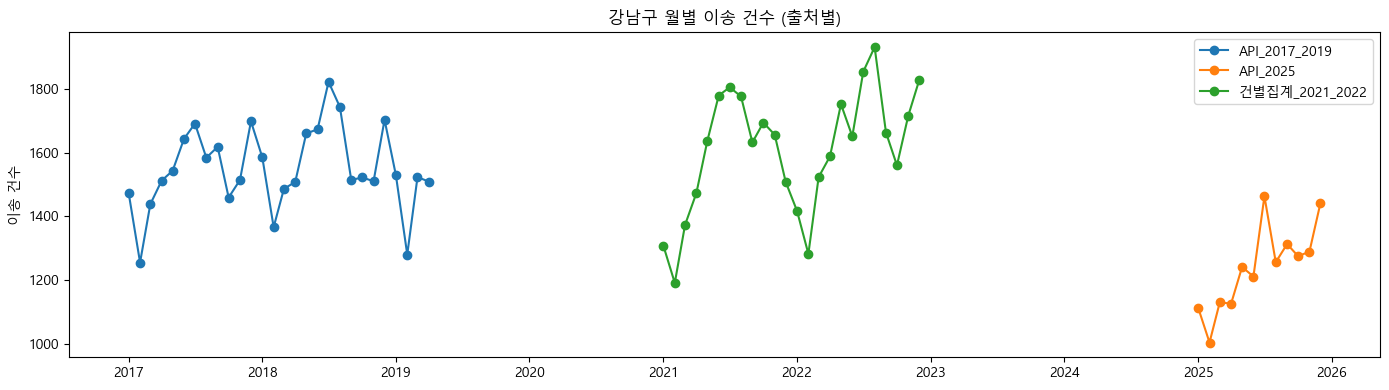

In [3]:
print(full.groupby('출처')[target].mean().round(0))

gu = '강남구'
part = full[full['District'] == gu]

plt.figure(figsize=(14, 4))
for src, g in part.groupby('출처'):
    plt.plot(g['ds'], g[target], marker='o', label=src)
plt.title(f'{gu} 월별 이송 건수 (출처별)')
plt.ylabel('이송 건수')
plt.legend()
plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/transport_source_gap.png')
plt.show()

## 3. 실험용 데이터 2종 만들기
- 데이터 A : 12개 컬럼, 575행 (의료이용 지표 포함, 행 적음)
- 데이터 B : 7개 컬럼, 1,138행 (max_missing=0.3 기준, 의료이용 지표 빠짐, 행 많음)
- 결측 처리 : 빈 값이 있는 행 제거 (dropna), 빈 기간을 임의 값으로 채우지 않음

In [4]:
features_A = [c for c in sel.columns if c not in ['ds', 'District', '출처', target]]

features_B = ['전월_transport_cnt', '전월_Night_Pop', '전월_동일자치구행정동간이동인구수',
              '전월_일최대인구수', '전년_인명갇힘', '전년_승강기사고', '연도']

data_A = sel.copy()
data_B = full[['ds', 'District', '출처'] + features_B + [target]].dropna().reset_index(drop=True)

print('데이터 A :', data_A.shape, features_A)
print('데이터 B :', data_B.shape, features_B)
print('B에서 빈 값 때문에 빠진 행 :', len(full) - len(data_B))

데이터 A : (575, 16) ['전월_transport_cnt', '전년_서울외유출연인원', '전년동월_y', '전년_서울내입원연인원', '전월_Night_Pop', '전월_동일자치구행정동간이동인구수', '전월_일최대인구수', '전년_총처리연인원', '전년_인명갇힘', '전년_서울내환자연인원', '전년_승강기사고', '연도']
데이터 B : (1138, 11) ['전월_transport_cnt', '전월_Night_Pop', '전월_동일자치구행정동간이동인구수', '전월_일최대인구수', '전년_인명갇힘', '전년_승강기사고', '연도']
B에서 빈 값 때문에 빠진 행 : 428


## 4. 데이터셋 분할 (날짜 기준)
- 시간 순서 분할 : 과거로 학습, 최근으로 평가 (미래 정보 누출 방지)
- 시험 데이터 : 2025년 9~12월 (A·B 모두 같은 100행이라 공정한 비교 가능)

In [5]:
split_date = '2025-09-01'

for name, d in [('A', data_A), ('B', data_B)]:
    n_train = (d['ds'] < split_date).sum()
    n_test = (d['ds'] >= split_date).sum()
    print(f'데이터 {name} - 학습 : {n_train}행 / 시험 : {n_test}행')

데이터 A - 학습 : 475행 / 시험 : 100행
데이터 B - 학습 : 1038행 / 시험 : 100행


## 5. 함수 준비
- make_xy : 컬럼 선택 + 원-핫 인코딩 + 학습/시험 분할
- 출처 원-핫 : 출처별 집계 기준 차이를 모델이 따로 반영
- evaluate : MAE, RMSE, R2, 정확도(%) 계산
- build_dnn : 강의자료 방식 DNN (Dense → Dropout)

In [6]:
def make_xy(df, features, use_source):
    cols = features + ['District']
    dummy_cols = ['District']
    if use_source:
        cols.append('출처')
        dummy_cols.append('출처')

    X = pd.get_dummies(df[cols], columns=dummy_cols, dtype=int)
    y = df[target]
    train = df['ds'] < split_date
    test = df['ds'] >= split_date
    return X[train], X[test], y[train], y[test]


def evaluate(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred),
        '정확도(%)': (1 - mean_absolute_percentage_error(y_true, y_pred)) * 100
    }


def build_dnn(n_input):
    model = Sequential([
        Input(shape=(n_input,)),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(loss='mse', optimizer='adam', metrics=['mae'])
    return model

## 6. 실험 4개 × 모델 6종 학습
- 머신러닝 5종 : 선형회귀, 릿지, 결정트리, 랜덤포레스트, 그래디언트부스팅
- 딥러닝 1종 : DNN (타겟도 스케일 조정 후 inverse_transform으로 복원)
- StandardScaler : fit은 학습 데이터에만
- EarlyStopping : 검증 오차 개선이 없으면 학습 중단

In [7]:
experiments = {
    'A_출처O': (data_A, features_A, True),
    'A_출처X': (data_A, features_A, False),
    'B_출처O': (data_B, features_B, True),
    'B_출처X': (data_B, features_B, False),
}

results = []
saved = {}   # 실험별 학습 결과 보관

for exp_name, (df, features, use_source) in experiments.items():
    X_train, X_test, y_train, y_test = make_xy(df, features, use_source)

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    models = {
        'LinearRegression': LinearRegression(),
        'Ridge': Ridge(alpha=1.0),
        'DecisionTree': DecisionTreeRegressor(max_depth=5, random_state=42),
        'RandomForest': RandomForestRegressor(n_estimators=200, random_state=42),
        'GradientBoosting': GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
    }
    preds = {}

    for name, model in models.items():
        model.fit(X_train_s, y_train)
        preds[name] = model.predict(X_test_s)

    y_scaler = StandardScaler()
    y_train_s = y_scaler.fit_transform(y_train.values.reshape(-1, 1))
    dnn = build_dnn(X_train_s.shape[1])
    dnn.fit(X_train_s, y_train_s, epochs=500, batch_size=16, validation_split=0.2,
            callbacks=[EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)],
            verbose=0)
    preds['DNN'] = y_scaler.inverse_transform(dnn.predict(X_test_s, verbose=0)).flatten()
    models['DNN'] = dnn

    for name, pred in preds.items():
        results.append({'실험': exp_name, '모델': name, **evaluate(y_test, pred)})

    saved[exp_name] = {'models': models, 'preds': preds, 'scaler': scaler, 'y_scaler': y_scaler,
                       'columns': list(X_train.columns), 'y_test': y_test}
    print(exp_name, '완료 - 학습', X_train.shape, '/ 시험', X_test.shape)

A_출처O 완료 - 학습 (475, 39) / 시험 (100, 39)
A_출처X 완료 - 학습 (475, 37) / 시험 (100, 37)
B_출처O 완료 - 학습 (1038, 35) / 시험 (100, 35)
B_출처X 완료 - 학습 (1038, 32) / 시험 (100, 32)


## 7. 결과 비교 및 최고 조합 선택
- 정렬 기준 : 정확도(%) 내림차순
- 최고 조합 저장 : 모델(pickle 또는 h5) + 스케일러 + 컬럼 목록

In [8]:
result_df = pd.DataFrame(results).sort_values('정확도(%)', ascending=False).reset_index(drop=True)
print(result_df.round(3).head(10))
result_df.to_csv(f'{RESULT_DIR}/transport_model_score.csv', index=False, encoding='utf-8-sig')

best_exp = result_df.loc[0, '실험']
best_name = result_df.loc[0, '모델']
best = saved[best_exp]
best_pred = best['preds'][best_name]
y_test = best['y_test']
print('최고 조합 :', best_exp, '/', best_name)

if best_name == 'DNN':
    best['models']['DNN'].save(f'{RESULT_DIR}/transport_best_model.h5')
else:
    with open(f'{RESULT_DIR}/transport_best_model.pkl', 'wb') as f:
        pickle.dump(best['models'][best_name], f)

with open(f'{RESULT_DIR}/transport_scaler.pkl', 'wb') as f:
    pickle.dump({'scaler': best['scaler'], 'y_scaler': best['y_scaler'], 'columns': best['columns']}, f)

      실험                모델     MAE    RMSE     R2  정확도(%)
0  B_출처X             Ridge  36.123  44.341  0.961  96.185
1  B_출처X  LinearRegression  36.131  44.372  0.961  96.181
2  B_출처O             Ridge  39.756  48.638  0.954  95.883
3  B_출처O  LinearRegression  39.878  48.752  0.953  95.869
4  B_출처O  GradientBoosting  41.066  51.479  0.948  95.605
5  B_출처O      RandomForest  41.545  51.602  0.948  95.555
6  A_출처X      RandomForest  43.165  56.625  0.937  95.531
7  B_출처X      RandomForest  41.798  52.054  0.947  95.525
8  A_출처O      RandomForest  43.319  56.716  0.937  95.507
9  B_출처X  GradientBoosting  42.288  53.523  0.944  95.499
최고 조합 : B_출처X / Ridge


## 7-1. 기준선(전월 값 그대로)과 비교
- 기준선 : 모델 없이 "이번 달 = 지난달" 이라고 예측하는 가장 단순한 방법
- 목적 : 모델이 단순 복사보다 실제로 나은지 확인
- 해석 : 차이가 작으면 모델이 전월 값에 대부분 의존한다는 뜻

기준선 정확도(%) : 96.0 / R2 : 0.955
최고 조합 정확도(%) : 96.19
차이(%p) : 0.19


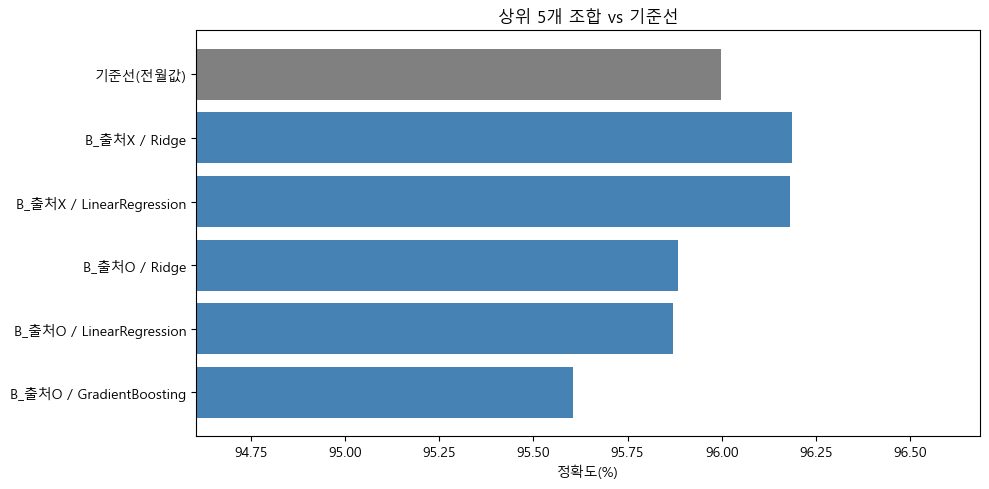

In [9]:
baseline_pred = data_B.loc[data_B['ds'] >= split_date, '전월_transport_cnt']
baseline_true = data_B.loc[data_B['ds'] >= split_date, target]
baseline = evaluate(baseline_true, baseline_pred)
print('기준선 정확도(%) :', round(baseline['정확도(%)'], 2), '/ R2 :', round(baseline['R2'], 3))
print('최고 조합 정확도(%) :', round(result_df.loc[0, '정확도(%)'], 2))
print('차이(%p) :', round(result_df.loc[0, '정확도(%)'] - baseline['정확도(%)'], 2))

top5 = result_df.head(5)
labels = ['기준선(전월값)'] + (top5['실험'] + ' / ' + top5['모델']).tolist()
values = [baseline['정확도(%)']] + top5['정확도(%)'].tolist()

plt.figure(figsize=(10, 5))
plt.barh(labels[::-1], values[::-1], color=['steelblue'] * 5 + ['gray'])
plt.xlim(min(values) - 1, max(values) + 0.5)
plt.xlabel('정확도(%)')
plt.title('상위 5개 조합 vs 기준선')
plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/transport_vs_baseline.png')
plt.show()

## 8. 시각화 ① 실험 × 모델 정확도 히트맵
- 가로 비교 : 같은 실험 안에서 모델 차이
- 세로 비교 : 데이터 A·B, 출처 사용 여부에 따른 차이

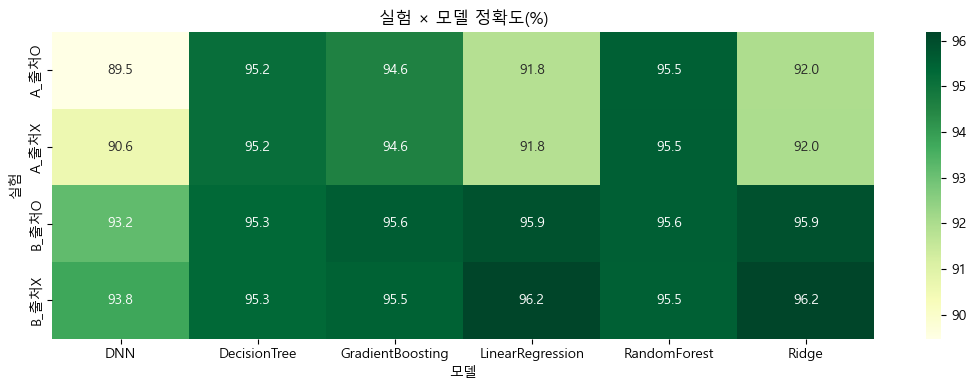

In [10]:
score_table = result_df.pivot_table(index='실험', columns='모델', values='정확도(%)')

plt.figure(figsize=(11, 4))
sns.heatmap(score_table, annot=True, fmt='.1f', cmap='YlGn')
plt.title('실험 × 모델 정확도(%)')
plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/transport_model_compare.png')
plt.show()

## 9. 시각화 ② 실제값 vs 예측값 산점도
- 대각선(y=x) : 완벽한 예측선
- 점이 대각선에 가까울수록 정확한 예측

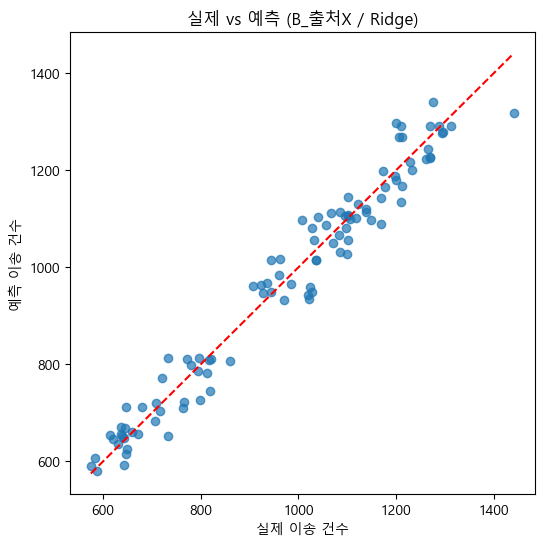

In [11]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_pred, alpha=0.7)
lim = [y_test.min(), y_test.max()]
plt.plot(lim, lim, 'r--')
plt.xlabel('실제 이송 건수')
plt.ylabel('예측 이송 건수')
plt.title(f'실제 vs 예측 ({best_exp} / {best_name})')
plt.savefig(f'{RESULT_DIR}/transport_scatter.png')
plt.show()

## 10. 시각화 ③ 자치구별 테스트 : 실제 vs 예측
- 시험 기간 : 2025년 9~12월 4개월 합계
- 묶음 막대그래프 : 자치구마다 실제·예측 나란히 표시

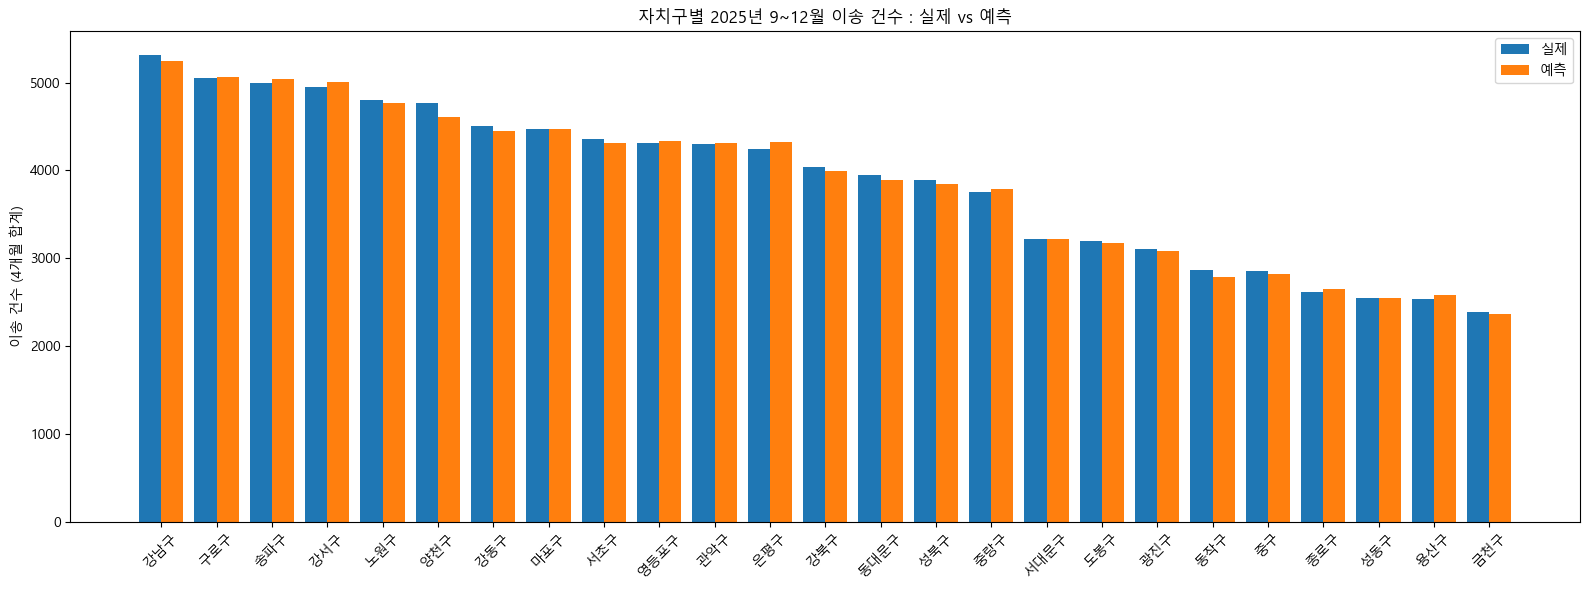

In [12]:
best_data = experiments[best_exp][0]
test_df = best_data.loc[y_test.index, ['ds', 'District', target]].copy()
test_df['예측'] = best_pred
test_df['오차율(%)'] = (test_df['예측'] - test_df[target]).abs() / test_df[target] * 100
test_df.to_csv(f'{RESULT_DIR}/transport_test_prediction.csv', index=False, encoding='utf-8-sig')

gu_sum = test_df.groupby('District')[[target, '예측']].sum().sort_values(target, ascending=False)

x = np.arange(len(gu_sum))
plt.figure(figsize=(16, 6))
plt.bar(x - 0.2, gu_sum[target], width=0.4, label='실제')
plt.bar(x + 0.2, gu_sum['예측'], width=0.4, label='예측')
plt.xticks(x, gu_sum.index, rotation=45)
plt.ylabel('이송 건수 (4개월 합계)')
plt.title('자치구별 2025년 9~12월 이송 건수 : 실제 vs 예측')
plt.legend()
plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/transport_district_bar.png')
plt.show()

## 11. 시각화 ④ 이송 건수 상위 4개 자치구의 2025년 추이
- 실선 : 2025년 실제값
- 빨간 점선 : 시험 기간 예측값

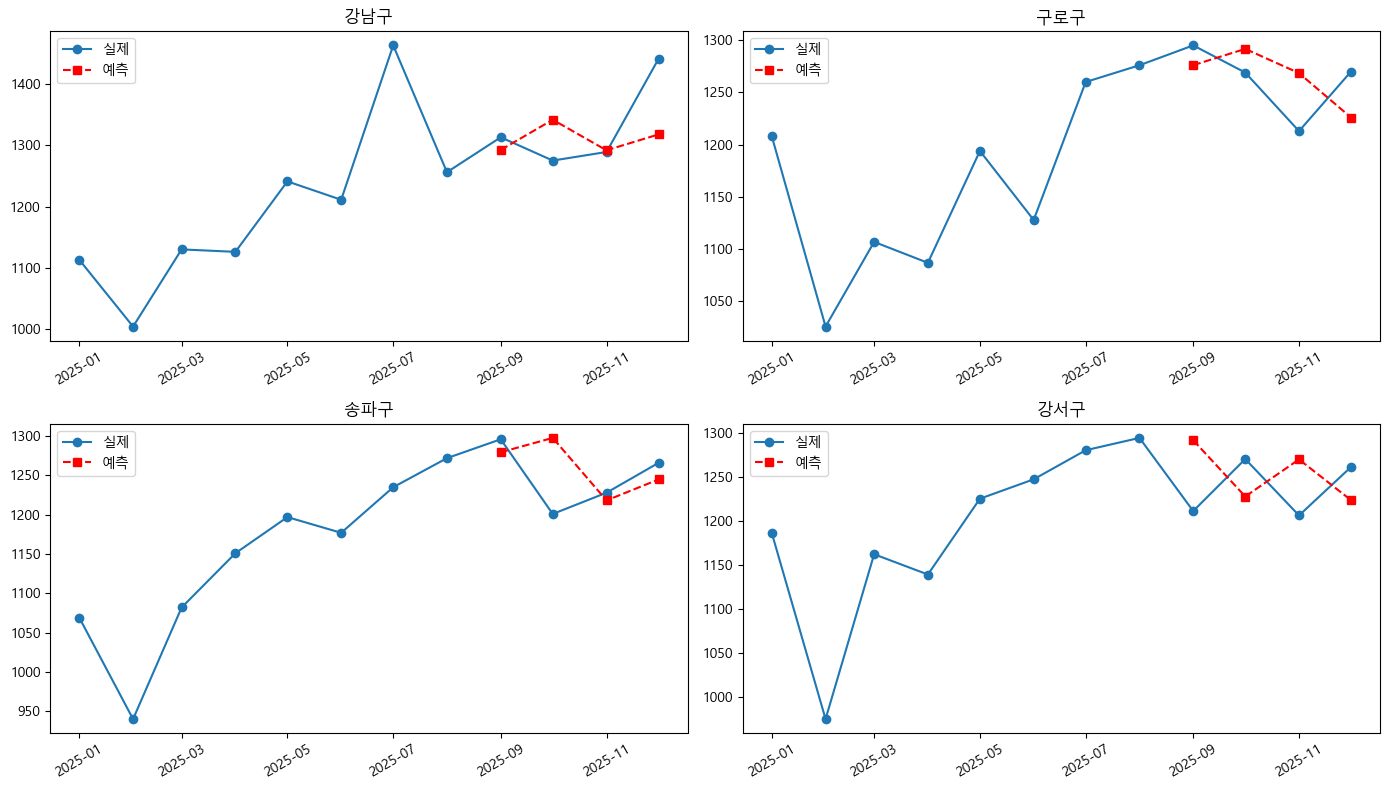

In [13]:
top4 = gu_sum.head(4).index
real_2025 = full[full['ds'].dt.year == 2025]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, g in zip(axes.flatten(), top4):
    real = real_2025[real_2025['District'] == g]
    pred = test_df[test_df['District'] == g]
    ax.plot(real['ds'], real[target], marker='o', label='실제')
    ax.plot(pred['ds'], pred['예측'], 'r--', marker='s', label='예측')
    ax.set_title(g)
    ax.tick_params(axis='x', rotation=30)
    ax.legend()
plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/transport_trend.png')
plt.show()

## 12. 시각화 ⑤ 자치구별 평균 오차율
- 오차율 : |예측 - 실제| / 실제 × 100
- 오차율 높은 자치구 : 추가 변수 검토 대상

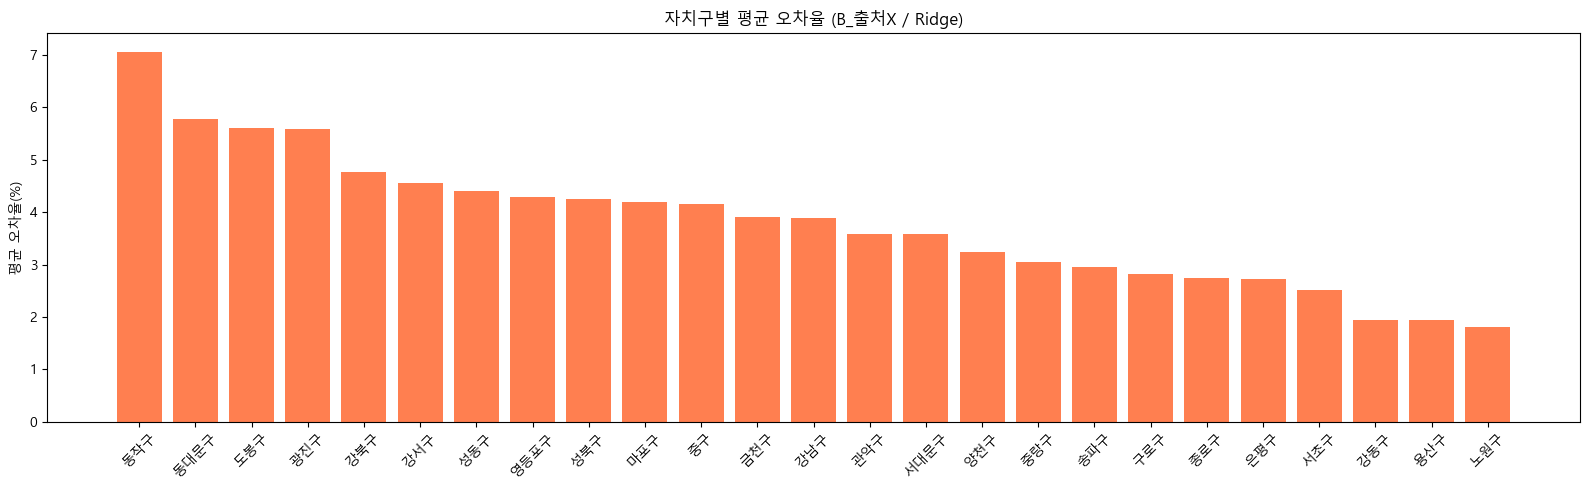

In [14]:
gu_err = test_df.groupby('District')['오차율(%)'].mean().sort_values(ascending=False)

plt.figure(figsize=(16, 5))
plt.bar(gu_err.index, gu_err.values, color='coral')
plt.xticks(rotation=45)
plt.ylabel('평균 오차율(%)')
plt.title(f'자치구별 평균 오차율 ({best_exp} / {best_name})')
plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/transport_district_error.png')
plt.show()

## 13. 특성 중요도 확인
- 목적 : 상관계수가 놓친 곡선 관계·여러 컬럼의 조합 효과 확인
- 기준 모델 : 최고 조합 실험의 RandomForest
- 중요도 원리 : 해당 컬럼으로 나눴을 때 오차가 줄어든 양의 합
- 원-핫 컬럼 합산 : District_, 출처_ 로 쪼개진 컬럼을 하나로 묶어서 보기

전월_transport_cnt     0.902
전월_Night_Pop         0.023
전월_일최대인구수            0.023
전월_동일자치구행정동간이동인구수    0.022
District(합계)         0.010
전년_승강기사고             0.008
전년_인명갇힘              0.008
연도                   0.004
dtype: float64


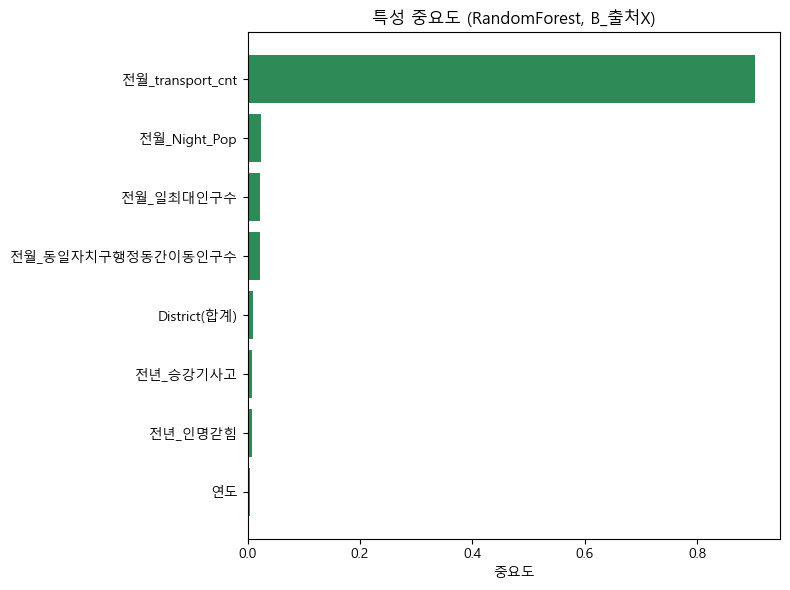

In [15]:
rf = best['models']['RandomForest']
imp = pd.Series(rf.feature_importances_, index=best['columns'])

for prefix in ['District_', '출처_']:
    cols = [c for c in imp.index if c.startswith(prefix)]
    if cols:
        imp[prefix.rstrip('_') + '(합계)'] = imp[cols].sum()
        imp = imp.drop(cols)

imp = imp.sort_values()
print(imp.sort_values(ascending=False).round(3))

plt.figure(figsize=(8, 6))
plt.barh(imp.index, imp.values, color='seagreen')
plt.xlabel('중요도')
plt.title(f'특성 중요도 (RandomForest, {best_exp})')
plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/transport_importance.png')
plt.show()